In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

In [7]:
data=fetch_california_housing()

X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred=model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error ,r2_score
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print("Mean squared Error:",mse)
print("R2 Score:",r2)

Mean squared Error: 0.555891598695244
R2 Score: 0.5757877060324511


In [15]:
coefficients=pd.DataFrame(model.coef_,X.columns,columns=['coefficients'])
print(coefficients)

            coefficients
MedInc          0.448675
HouseAge        0.009724
AveRooms       -0.123323
AveBedrms       0.783145
Population     -0.000002
AveOccup       -0.003526
Latitude       -0.419792
Longitude      -0.433708


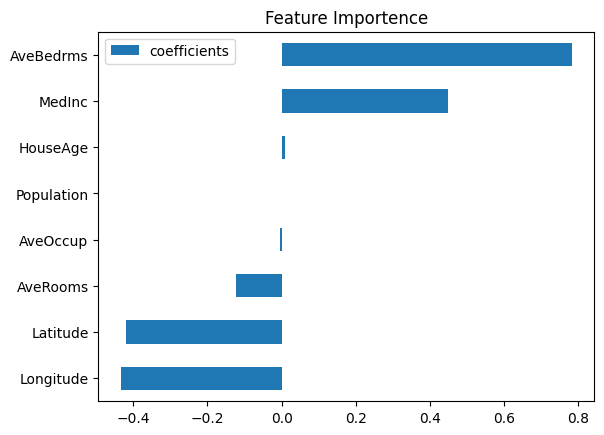

In [17]:
coefficients.sort_values(by='coefficients').plot(kind='barh')
plt.title("Feature Importence")
plt.show()

In [1]:
#OneHotencoding using pandas 
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


In [2]:
data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}
df=pd.DataFrame(data)
print("Original Data:\n",df)

Original Data:
    Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice


In [3]:
encoding=pd.get_dummies(df,columns=['Gender','Remarks'])
print("OneHotencoding using pandas :\n",encoding)

OneHotencoding using pandas :
    Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10     False      True          True          False         False
1           20      True     False         False          False          True
2           15      True     False          True          False         False
3           25     False      True         False           True         False
4           30      True     False         False          False          True


In [4]:
#Using Sklearn 
categorical_columns=['Gender','Remarks']
encoder=OneHotEncoder(sparse_output=False)
encoded_array=encoder.fit_transform(df[categorical_columns])
encoded_df=pd.DataFrame(encoded_array,columns=encoder.get_feature_names_out(categorical_columns))
final_df=pd.concat([df[['Employee id']],encoded_df],axis=1)
print("One Hot encoding using sklearn:\n",final_df)

One Hot encoding using sklearn:
    Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           20       1.0       0.0           0.0            0.0           1.0
2           15       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4           30       1.0       0.0           0.0            0.0           1.0


In [5]:
#correlation Matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets


In [7]:
data=datasets.load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
df.shape
df['Target']=data.target

In [13]:
matrix=df.corr()
print(matrix)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
Target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    Target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
Target                     0.956547  1.000000  


In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(matrix,annot=True,cmap='coolwarm')
plt.title("Correaltion matrix for iris dataset")
plt.show()